<a href="https://colab.research.google.com/github/dr-koehler-ai/Heart-Failure-Clinical-Records-Dashboard-V1/blob/main/Heart_Failure_Clinical_Records_Dashboard_V1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Heart Failure Clinical Records Dashboard (V1)
# =========================================

import kagglehub
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path


# =========================
# 1. Dataset Download
# =========================

!pip install ucimlrepo

from ucimlrepo import fetch_ucirepo

# fetch dataset
heart_failure_clinical_records = fetch_ucirepo(id=519)

# data (as pandas dataframes)
X = heart_failure_clinical_records.data.features
y = heart_failure_clinical_records.data.targets

# metadata
print(heart_failure_clinical_records.metadata)

# variable information
print(heart_failure_clinical_records.variables)

# adding death_event as variable
heart_failure_clinical_records = pd.DataFrame(X)
heart_failure_clinical_records["death_event"] = y

{'uci_id': 519, 'name': 'Heart Failure Clinical Records', 'repository_url': 'https://archive.ics.uci.edu/dataset/519/heart+failure+clinical+records', 'data_url': 'https://archive.ics.uci.edu/static/public/519/data.csv', 'abstract': 'This dataset contains the medical records of 299 patients who had heart failure, collected during their follow-up period, where each patient profile has 13 clinical features.', 'area': 'Health and Medicine', 'tasks': ['Classification', 'Regression', 'Clustering'], 'characteristics': ['Multivariate'], 'num_instances': 299, 'num_features': 12, 'feature_types': ['Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['death_event'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2020, 'last_updated': 'Mon Feb 26 2024', 'dataset_doi': '10.24432/C5Z89R', 'creators': [], 'intro_paper': {'ID': 286, 'type': 'NATIVE', 'title': 'Machine learning can predict survival of patients with heart failure f

In [2]:
# =========================
# 2. Dataset Overview
# =========================

print("Number of rows and columns:", heart_failure_clinical_records.shape)
print("Overview:", heart_failure_clinical_records.describe())
print("Variables:", heart_failure_clinical_records.columns.to_list())
print("Table Head:",heart_failure_clinical_records.head(10))


Number of rows and columns: (299, 13)
Overview:               age     anaemia  creatinine_phosphokinase    diabetes  \
count  299.000000  299.000000                299.000000  299.000000   
mean    60.833893    0.431438                581.839465    0.418060   
std     11.894809    0.496107                970.287881    0.494067   
min     40.000000    0.000000                 23.000000    0.000000   
25%     51.000000    0.000000                116.500000    0.000000   
50%     60.000000    0.000000                250.000000    0.000000   
75%     70.000000    1.000000                582.000000    1.000000   
max     95.000000    1.000000               7861.000000    1.000000   

       ejection_fraction  high_blood_pressure      platelets  \
count         299.000000           299.000000     299.000000   
mean           38.083612             0.351171  263358.029264   
std            11.834841             0.478136   97804.236869   
min            14.000000             0.000000   25100.00

In [3]:

# =========================
# 3. Missing Data Analysis
# =========================

missing = heart_failure_clinical_records.isnull().mean().sort_values(ascending=False)
print("\nTop Missing Values:\n", missing.head(15))
print("There are no missing values")


Top Missing Values:
 age                         0.0
anaemia                     0.0
creatinine_phosphokinase    0.0
diabetes                    0.0
ejection_fraction           0.0
high_blood_pressure         0.0
platelets                   0.0
serum_creatinine            0.0
serum_sodium                0.0
sex                         0.0
smoking                     0.0
time                        0.0
death_event                 0.0
dtype: float64
There are no missing values


In [4]:
# =========================
# 4. Exploratory Data Analysis
# =========================

heartfailure_by_target = heart_failure_clinical_records.groupby("death_event").agg({
    "age": ["mean", "min", "max"],
    "anaemia": ["mean"],
    "creatinine_phosphokinase": ["mean", "min", "max"],
    "diabetes": ["mean"],
    "ejection_fraction": ["mean", "min", "max"],
    "high_blood_pressure": ["mean"],
    "platelets": ["mean"],
    "serum_creatinine": ["mean", "min", "max"],
    "serum_sodium": ["mean"],
    "smoking": ["mean"],
    "time": ["mean"]
})

print(heartfailure_by_target.head())

# flatten columns
heartfailure_by_target.columns = [
    f"{col[0]}_{col[1]}" if isinstance(col, tuple) else col
    for col in heartfailure_by_target.columns
]

heartfailure_by_target = heartfailure_by_target.rename(columns={"Death_Event": "Patient"})


print("\nFinal dataset shape:", heartfailure_by_target.shape)

                   age               anaemia creatinine_phosphokinase      \
                  mean   min   max      mean                     mean min   
death_event                                                                 
0            58.761906  40.0  90.0  0.408867               540.054187  30   
1            65.215281  42.0  95.0  0.479167               670.197917  23   

                   diabetes ejection_fraction         high_blood_pressure  \
              max      mean              mean min max                mean   
death_event                                                                 
0            5209  0.418719          40.26601  17  80            0.325123   
1            7861  0.416667          33.46875  14  70            0.406250   

                 platelets serum_creatinine           serum_sodium   smoking  \
                      mean             mean  min  max         mean      mean   
death_event                                                         

Outcome distribution:
death_event
0    203
1     96
Name: count, dtype: int64
Mortality rate: 32.1%


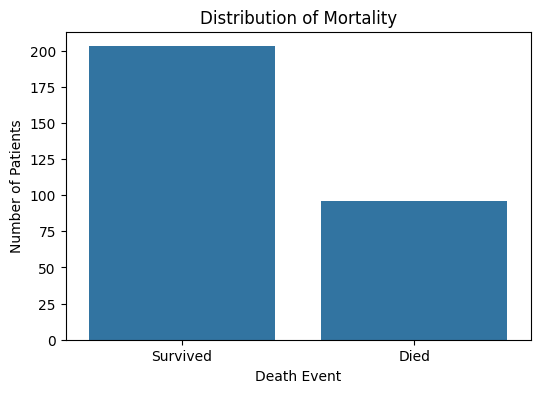

In [5]:
# =========================
# 5. Target Variable
# =========================

print("Outcome distribution:")
print(heart_failure_clinical_records["death_event"].value_counts())
mortality_rate = heart_failure_clinical_records["death_event"].mean()

print(f"Mortality rate: {mortality_rate:.1%}")
plt.figure(figsize=(6,4))

sns.countplot(
    data=heart_failure_clinical_records,
    x="death_event"
)

plt.title("Distribution of Mortality")
plt.xlabel("Death Event")
plt.ylabel("Number of Patients")
plt.xticks([0, 1], ["Survived", "Died"])
plt.show()

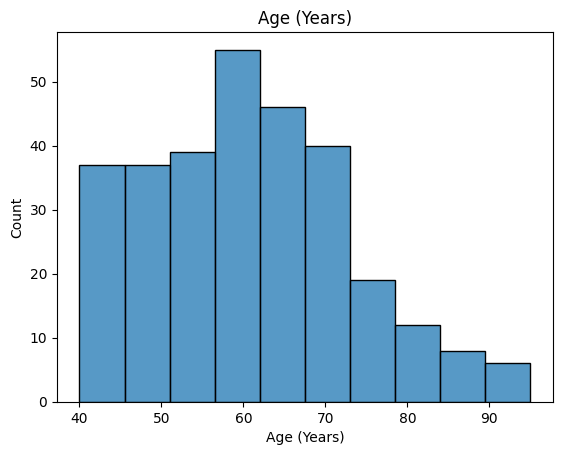

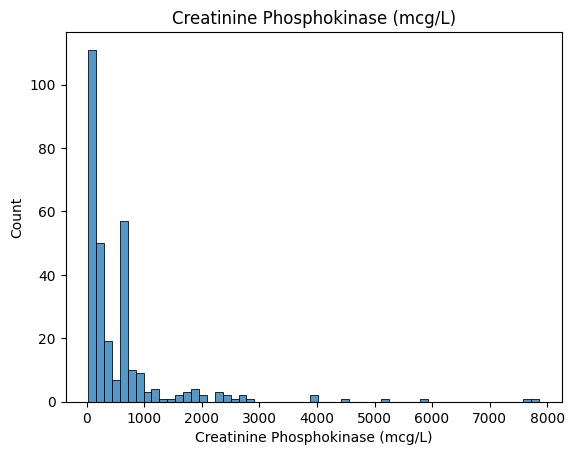

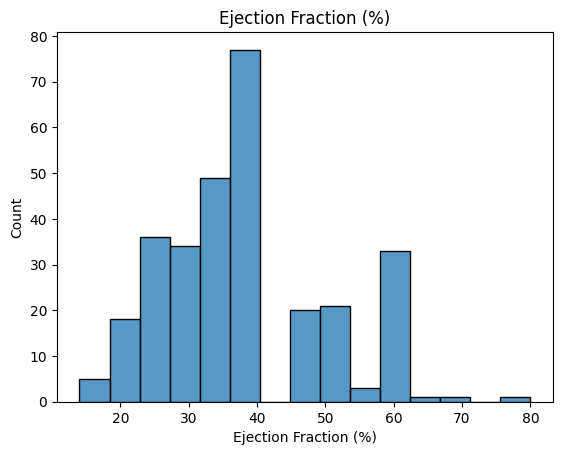

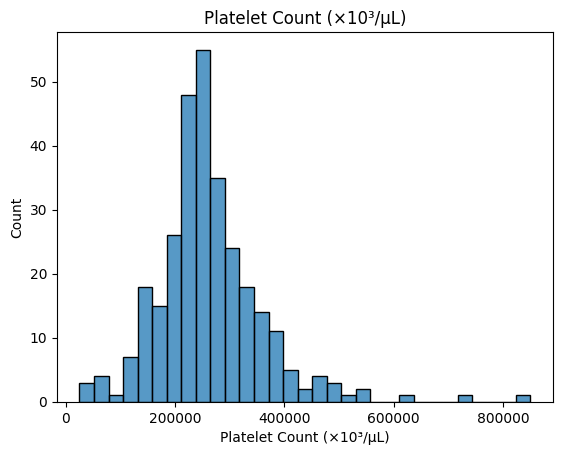

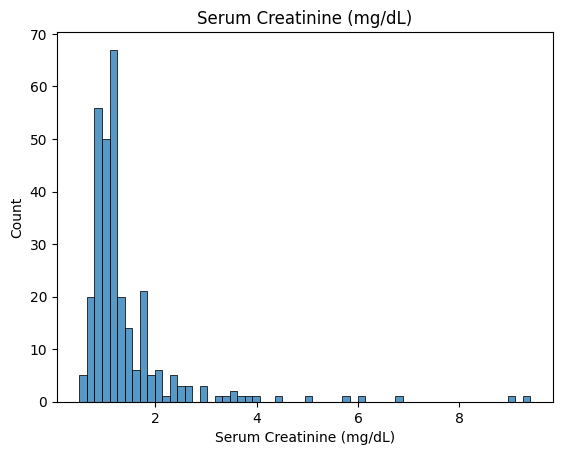

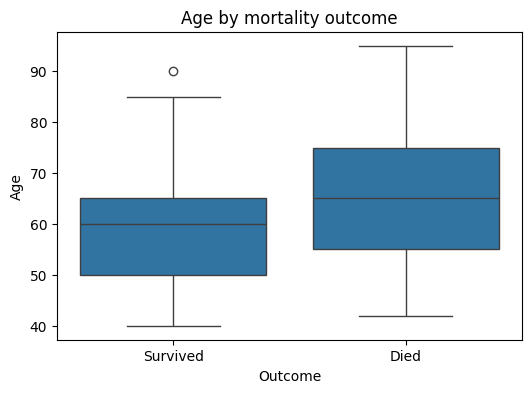

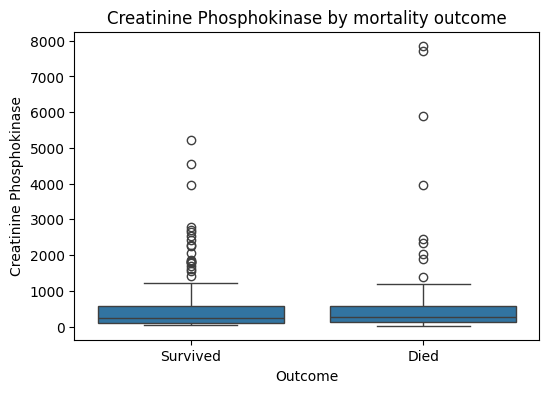

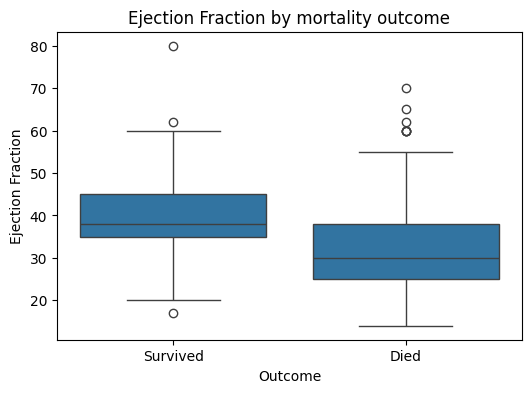

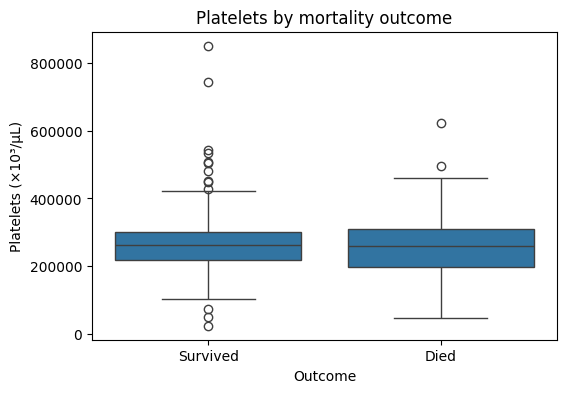

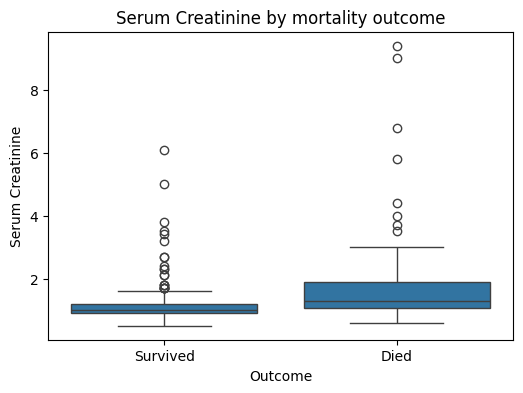

In [11]:
# ==================================================
# 6. Univariate Analysis of Continuous variables
# ==================================================
continuous_features = [
    "age",
    "creatinine_phosphokinase",
    "ejection_fraction",
    "platelets",
    "serum_creatinine",
]

variable_labels = {
    "age": "Age (Years)",
    "creatinine_phosphokinase": "Creatinine Phosphokinase (mcg/L)",
    "ejection_fraction": "Ejection Fraction (%)",
    "platelets": "Platelet Count (×10³/µL)",
    "serum_creatinine": "Serum Creatinine (mg/dL)"
}

def var_histogramms(x):
  for feat in x:
    label = variable_labels.get(feat, feat)
    sns.histplot(data=heart_failure_clinical_records, x=feat)
    plt.title(label)
    plt.xlabel(label)
    plt.show()
  return

var_histogramms(continuous_features)

for feature in continuous_features:

    plt.figure(figsize=(6,4))

    sns.boxplot(
        data=heart_failure_clinical_records,
        x="death_event",
        y=feature
    )

    plt.xticks(
        [0,1],
        ["Survived", "Died"]
    )

    plt.title(f"{feature.replace('_', ' ').title()} by mortality outcome")
    plt.xlabel("Outcome")

    if feature == "platelets":
        plt.ylabel("Platelets (×10³/µL)")
        plt.ticklabel_format(
            style="plain",
            axis="y"
        )
    else:
        plt.ylabel(feature.replace('_', ' ').title())

    plt.show()

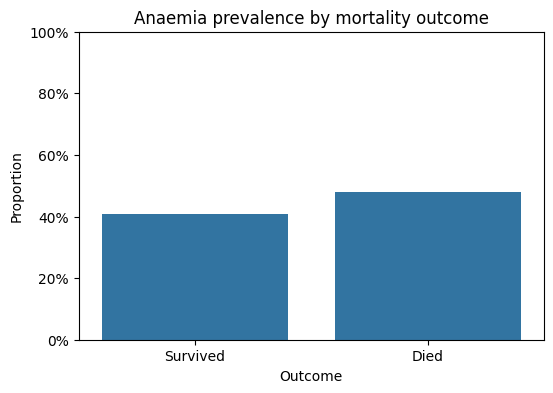

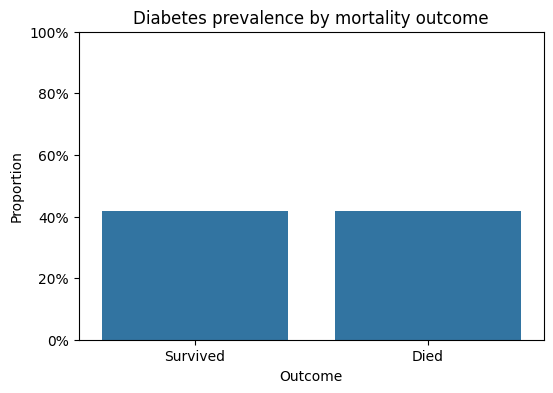

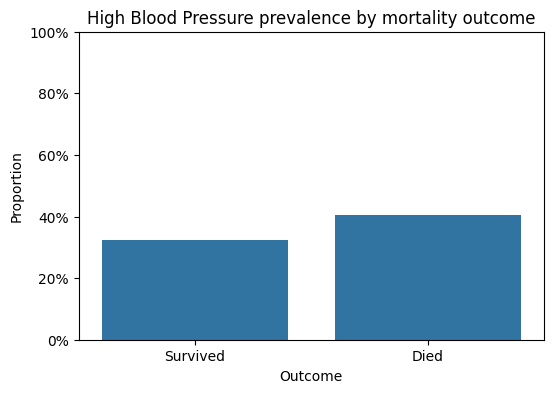

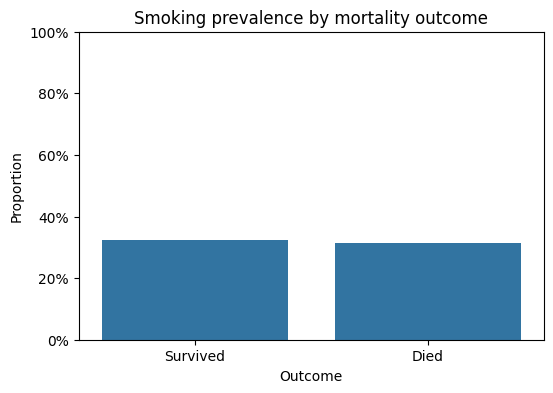

In [8]:
# ==================================================
# 6. Univariate Analysis of Binary variables
# ==================================================

categorical_features = [
    "anaemia",
    "diabetes",
    "high_blood_pressure",
    "smoking"
]

import matplotlib.ticker as mtick

for feature in categorical_features:

    plt.figure(figsize=(6,4))

    sns.barplot(
        data=heart_failure_clinical_records,
        x="death_event",
        y=feature,
        errorbar=None
    )

    plt.xticks(
        [0,1],
        ["Survived", "Died"]
    )

    plt.title(f"{feature.replace('_', ' ').title()} prevalence by mortality outcome")
    plt.xlabel("Outcome")
    plt.ylabel("Proportion")
    plt.ylim(0,1)
    plt.gca().yaxis.set_major_formatter(
    mtick.PercentFormatter(1.0)
)

    plt.show()

In [16]:
# =========================
# 7. Statistical Analysis
# =========================

from scipy import stats

continuous_features = [
    "age",
    "creatinine_phosphokinase",
    "ejection_fraction",
    "platelets",
    "serum_creatinine",
]

non_normal_features = [
    "creatinine_phosphokinase",
    "serum_creatinine"
]

categorical_features = [
    "anaemia",
    "diabetes",
    "high_blood_pressure",
    "smoking"
]

death_patients = heart_failure_clinical_records[heart_failure_clinical_records["death_event"] == 1]
non_death_patients = heart_failure_clinical_records[heart_failure_clinical_records["death_event"] == 0]


def compare_groups(features, test_name="welch"):

    print(f"\n{'='*60}")
    print(f"{test_name.upper()} TEST")
    print(f"{'='*60}")

    for feature in features:

        group1 = death_patients[feature].dropna()
        group2 = non_death_patients[feature].dropna()

        if test_name == "welch":
            statistic, p_value = stats.ttest_ind(
                group1,
                group2,
                equal_var=False
            )

        elif test_name == "mannwhitney":
            statistic, p_value = stats.mannwhitneyu(
                group1,
                group2,
                alternative="two-sided"
            )

        print(
            f"{feature:<20}"
            f"Statistic = {statistic:>10.2f}"
            f"   p = {p_value:.3e}"
        )
def compare_categorical(features):

    print(f"\n{'='*60}")
    print("CHI-SQUARE TEST")
    print(f"{'='*60}")

    for feature in features:

        table = pd.crosstab(
            heart_failure_clinical_records[feature],
            heart_failure_clinical_records["death_event"]
        )

        chi2, p_value, dof, expected = stats.chi2_contingency(table)

        print(
            f"{feature:<25}"
            f"Chi2={chi2:>10.2f}"
            f" p={p_value:.3e}"
        )


compare_groups(continuous_features, test_name="welch")
compare_groups(non_normal_features, test_name="mannwhitney")
compare_categorical(categorical_features)


WELCH TEST
age                 Statistic =       4.19   p = 4.735e-05
creatinine_phosphokinaseStatistic =       0.90   p = 3.692e-01
ejection_fraction   Statistic =      -4.57   p = 9.647e-06
platelets           Statistic =      -0.84   p = 3.993e-01
serum_creatinine    Statistic =       4.15   p = 6.399e-05

MANNWHITNEY TEST
creatinine_phosphokinaseStatistic =   10028.00   p = 6.840e-01
serum_creatinine    Statistic =   14190.00   p = 1.581e-10

CHI-SQUARE TEST
anaemia                  Chi2=      1.04 p=3.073e-01
diabetes                 Chi2=      0.00 p=1.000e+00
high_blood_pressure      Chi2=      1.54 p=2.141e-01
smoking                  Chi2=      0.01 p=9.318e-01
